In [1]:
import numpy as np
import pandas as pd

TRAIN = 'data/train.csv'
TEST = 'data/test.csv'

train = pd.read_csv(TRAIN)
test = pd.read_csv(TEST)

In [2]:
print(train.head(2))
print(test.head(2))

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         0         0  
1         0         0         0         0  

[2 rows x 785 columns]
   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0      

In [3]:
print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


In [4]:
X_train = train.drop(columns=['label'])
y_train = train['label']
X_test = test

In [5]:
# Normalize pixel values to [0, 1]
X_train = (X_train / 255.0).values
X_test = (X_test / 255.0).values

# Reshape for CNN input
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)

(42000, 28, 28, 1)


In [6]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
print(y_train.shape)

(42000, 10)


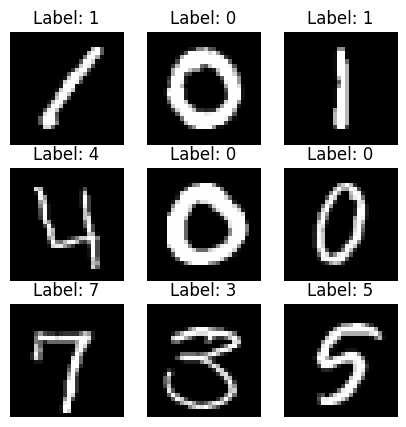

In [7]:
plt.figure(figsize=(5, 5))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {np.argmax(y_train[i])}')
    plt.axis('off')
plt.show()

In [8]:
model = Sequential()

model.add((Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))))
model.add(MaxPooling2D((2, 2), strides=2))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2), strides=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

d:\VOAI25\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9510 - loss: 0.1617 - val_accuracy: 0.9812 - val_loss: 0.0570
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9844 - loss: 0.0498 - val_accuracy: 0.9860 - val_loss: 0.0448
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9838 - val_loss: 0.0536
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9918 - loss: 0.0255 - val_accuracy: 0.9848 - val_loss: 0.0463
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9936 - loss: 0.0190 - val_accuracy: 0.9864 - val_loss: 0.0486
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9956 - loss: 0.0144 - val_accuracy: 0.9917 - val_loss: 0.0303
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9959 - loss: 0.0122 - val_accuracy: 0.9900 - val_loss: 0.0387
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9971 - loss: 0.0095 - 

In [10]:
preds = model.predict(X_test)
preds_label = preds.argmax(axis=1)

print(preds_label)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[2 0 9 ... 3 9 2]


In [ ]:
submission = pd.DataFrame({
    'ImageId': range(1, len(preds_label) + 1),
    'Label': preds_label
})

submission.to_csv('submissions/baseline.csv', index=False)

In [ ]:
# 0.98703